In [ ]:
# Script to clone the repository and switch to the desired branch (ONLY FOR COLAB)

!git clone https://github.com/francescopausellii/uniform-coloring-ai.git
%cd uniform-coloring-ai
!git checkout feat/path-finding

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
# INPUT DEL PROBLEMA — due modalità alternative:
#  - INPUT_IMAGE: path di un'immagine da cui riconoscere la griglia (rete neurale)
#  - INPUT_GRID:  griglia definita a mano (usata se INPUT_IMAGE è None)
INPUT_IMAGE = "../grid_imgs/image2.png"
# INPUT_IMAGE = None

INPUT_GRID = [
    ["G", "B", "Y", "G"],
    ["Y", "G", "B", "B"],
    ["B", "Y", "G", "Y"],
    ["T", "B", "Y", "G"],
]

2026-06-16 18:47:16.152290: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-16 18:47:16.228444: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-16 18:47:16.286610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-16 18:47:16.364212: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-16 18:47:16.410917: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-16 18:47:16.608794: I tensorflow/core/platform/cpu_feature_gu

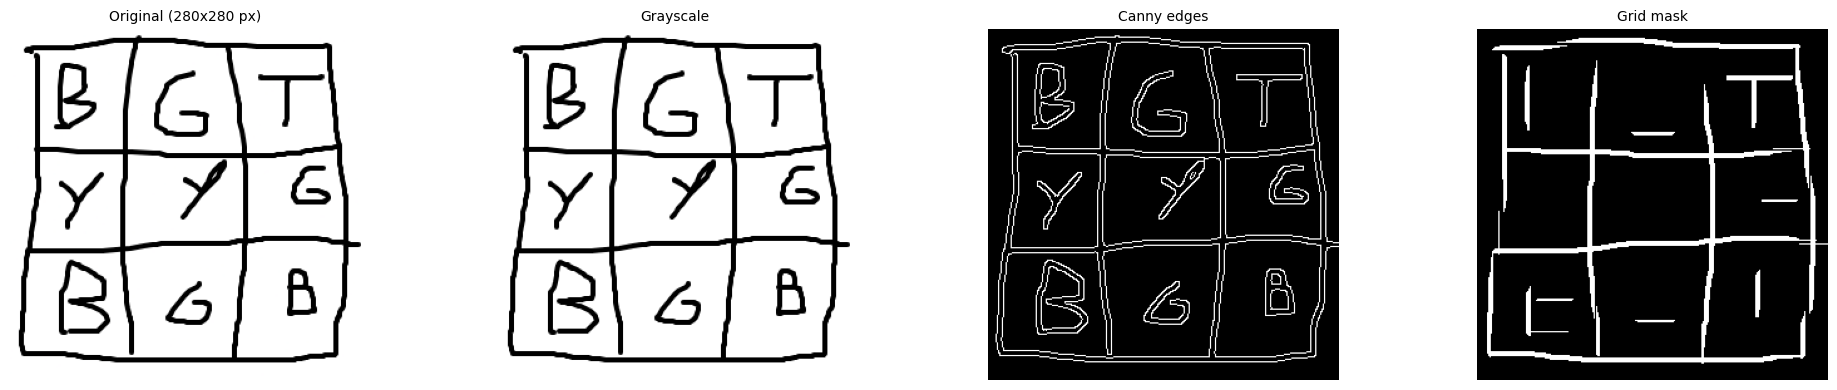

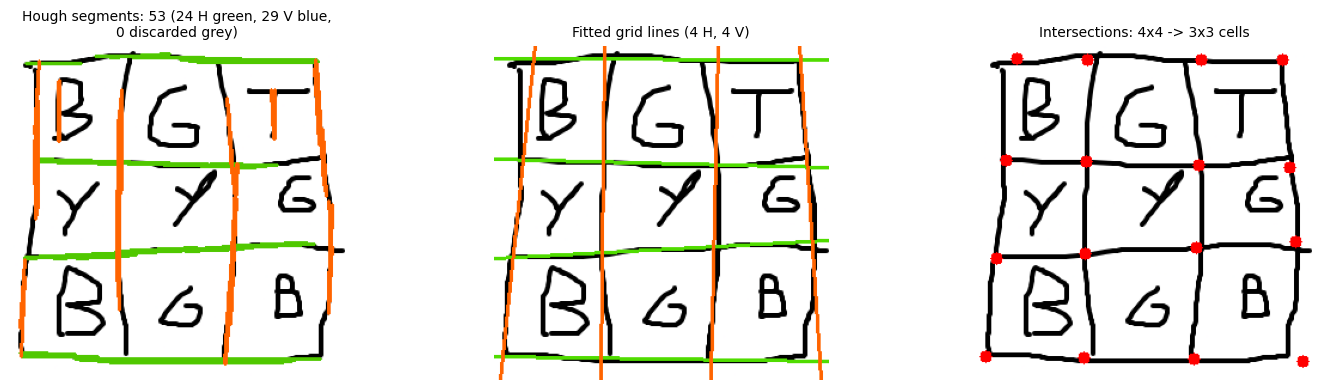

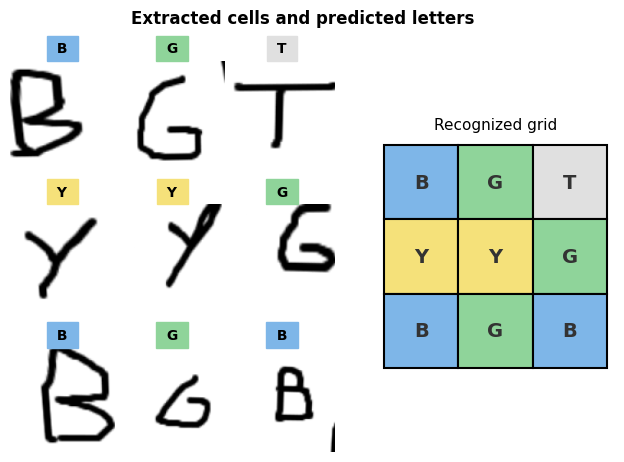

In [3]:
from grid_recognition import show_grid_matrix

if INPUT_IMAGE is not None:
    # Riconoscimento della griglia dall'immagine
    import keras
    from grid_recognition import (
        preparation,
        extract_grid_mask,
        detect_segments,
        classify_segments,
        segment_representative_position,
        cluster_lines_by_position,
        filter_clusters_by_span,
        build_grid_lines,
        compute_intersections,
        extract_all_cells,
        predict_grid,
        show_preprocessing,
        show_line_detection,
        show_recognition_result,
    )

    # Modello di riconoscimento lettere addestrato in model.ipynb
    model = keras.models.load_model("../models/dense.keras")

    # Carica l'immagine, la converte in scala di grigi e ne estrae i contorni (Canny)
    img, gray, edges = preparation(INPUT_IMAGE)

    # Isola le linee della griglia eliminando i tratti delle lettere
    grid_mask = extract_grid_mask(gray)
    show_preprocessing(img, gray, edges, grid_mask)

    # Rileva segmenti di linee con Hough, classificandoli in orizzontali e verticali
    segs = detect_segments(grid_mask)
    horiz, vert = classify_segments(segs)

    # Raggruppa i segmenti per posizione, scarta i tratti di lettere e fitta le linee
    horiz_cl = cluster_lines_by_position(segment_representative_position(horiz, "y"))
    vert_cl = cluster_lines_by_position(segment_representative_position(vert, "x"))
    horiz_cl, vert_cl = filter_clusters_by_span(horiz_cl, vert_cl)
    h_lines, v_lines = build_grid_lines(horiz_cl, vert_cl, img.shape)

    # Calcola le intersezioni tra le linee della griglia per ottenere i vertici delle celle
    pts = compute_intersections(h_lines, v_lines)
    show_line_detection(img, segs, horiz, vert, h_lines, v_lines, pts)

    # Ritaglia, raddrizza in prospettiva ed elimina i bordi neri da ogni quadratino
    cells_2d = extract_all_cells(gray, pts)

    # Passa ogni singola immagine ritagliata alla funzione che si interfaccia con la rete neurale
    grid_matrix = predict_grid(cells_2d, model)

    # Celle estratte con lettera predetta + griglia ricostruita, in un'unica figura
    show_recognition_result(cells_2d, grid_matrix)
else:
    # Griglia fornita a mano, nessun riconoscimento
    grid_matrix = INPUT_GRID
    show_grid_matrix(grid_matrix, "Manually provided grid")

In [5]:
from uniform_coloring.problem import UniformColoring
from uniform_coloring.search import (
    uniform_cost_search as ucs,
    breadth_first_graph_search as bfs,
    astar_search as astar,
)

# Problem Initialization: griglia riconosciuta dall'immagine o fornita a mano
problem = UniformColoring(grid_matrix)

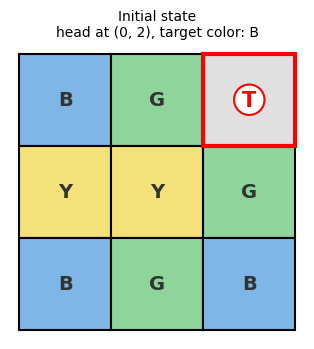

In [6]:
from uniform_coloring.visualization import plot_initial_state, plot_solution

# Initial State Visualization
plot_initial_state(problem)

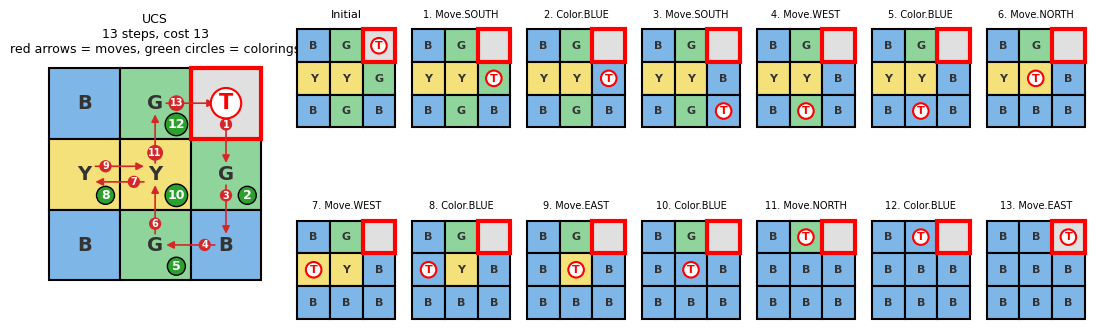

In [7]:
# UCS (Uniform Cost Search)
# Optimize the TOTAL COST, considering the weights of colors and movements
sol_ucs = ucs(problem)
plot_solution(problem, sol_ucs, "UCS")

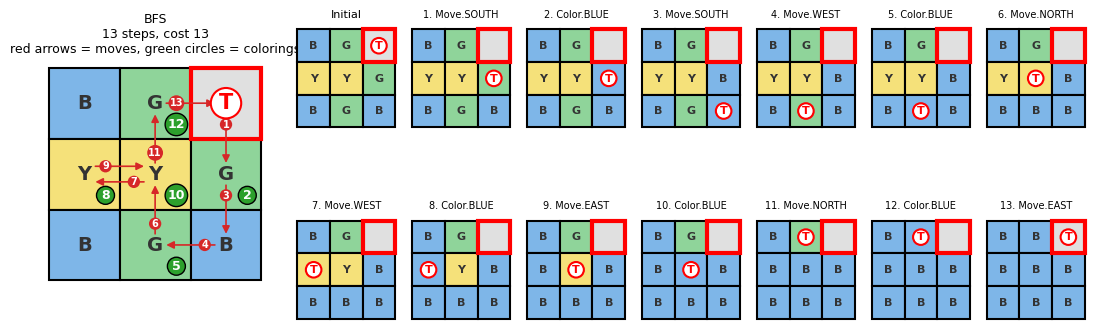

In [ ]:
# BFS ( Breadth First Search)
# Explores nodes level by level: finds the solution with fewest moves (optimal at uniform cost)
sol_bfs = bfs(problem)
plot_solution(problem, sol_bfs, "BFS")

Target color: B


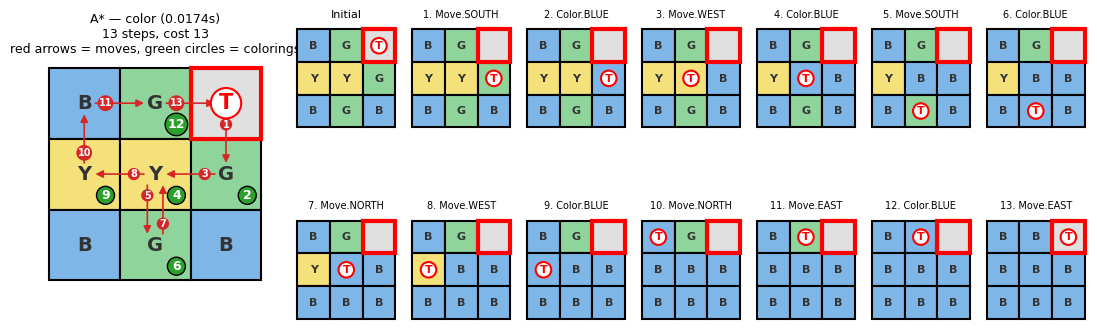

In [8]:
import time
from uniform_coloring.heuristics import Heuristics

h = Heuristics(problem)
print(f"Target color: {problem.target_color.symbol}")

# A* — color
t0 = time.perf_counter()
sol = astar(problem, h=h.color)
elapsed = time.perf_counter() - t0
plot_solution(problem, sol, f"A* — color ({elapsed:.4f}s)")

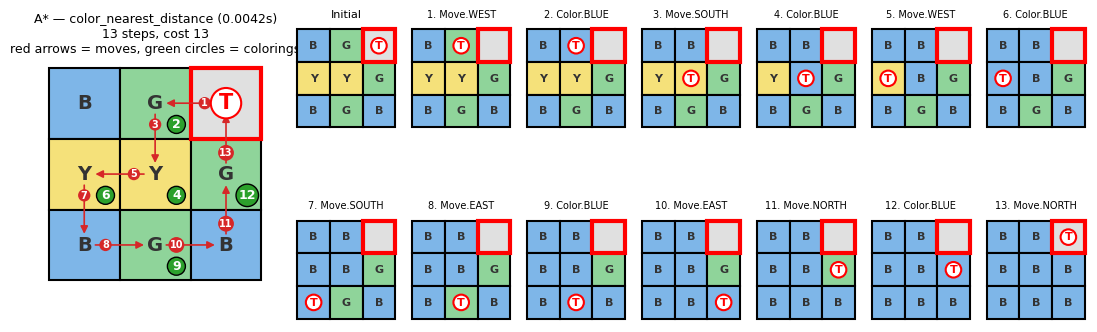

In [25]:
# A* — color_nearest_distance
t0 = time.perf_counter()
sol = astar(problem, h=h.color_nearest_distance)
elapsed = time.perf_counter() - t0
plot_solution(problem, sol, f"A* — color_nearest_distance ({elapsed:.4f}s)")

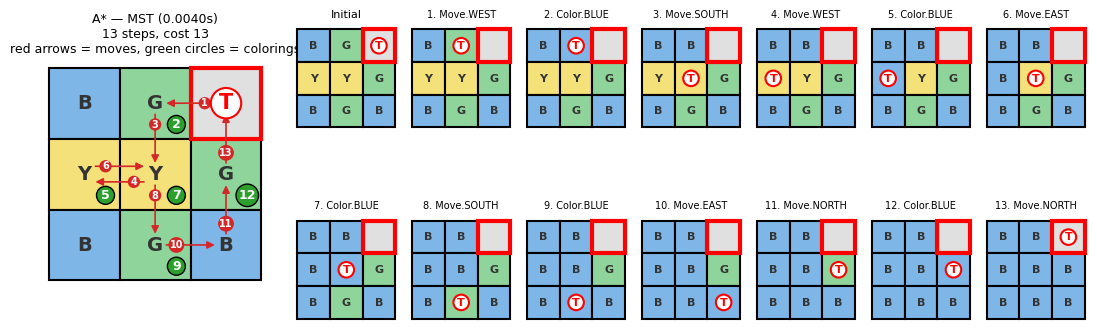

In [26]:
# A* — minimum_spanning_tree
t0 = time.perf_counter()
sol = astar(problem, h=h.mst)
elapsed = time.perf_counter() - t0
plot_solution(problem, sol, f"A* — MST ({elapsed:.4f}s)")

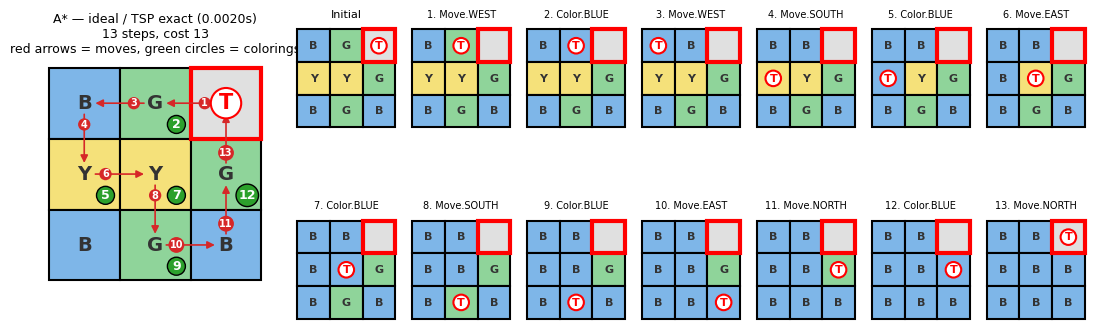

In [27]:
# A* — ideal / TSP exact (slow on large grids)
t0 = time.perf_counter()
sol = astar(problem, h=h.ideal)
elapsed = time.perf_counter() - t0
plot_solution(problem, sol, f"A* — ideal / TSP exact ({elapsed:.4f}s)")

In [9]:
%pip install jinja2

import importlib
import time
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FutTimeoutError

import uniform_coloring.search as _search_mod

importlib.reload(_search_mod)

from uniform_coloring.heuristics import Heuristics

TIMEOUT = 60  # secondi per singola esecuzione

h = Heuristics(problem)
n_cells = problem.rows * problem.cols

algorithms = [
    ("BFS", lambda: _search_mod.breadth_first_graph_search(problem)),
    ("UCS", lambda: _search_mod.uniform_cost_search(problem)),
    ("A* color", lambda: _search_mod.astar_search(problem, h=h.color)),
    (
        "A* color+dist",
        lambda: _search_mod.astar_search(problem, h=h.color_nearest_distance),
    ),
    ("A* MST", lambda: _search_mod.astar_search(problem, h=h.mst)),
]
# A* ideal: O(k!) per valutazione del nodo — praticabile solo su griglie piccole
if n_cells <= 9:
    algorithms.append(
        ("A* ideal", lambda: _search_mod.astar_search(problem, h=h.ideal))
    )


def run_with_timeout(fn, timeout):
    with ThreadPoolExecutor(max_workers=1) as ex:
        fut = ex.submit(fn)
        try:
            return fut.result(timeout=timeout)
        except FutTimeoutError:
            return "TIMEOUT"
        except Exception as e:
            return f"ERROR: {e}"


rows = []
for algo_name, fn in algorithms:
    t0 = time.perf_counter()
    sol = run_with_timeout(fn, TIMEOUT)
    elapsed = time.perf_counter() - t0

    if sol == "TIMEOUT":
        rows.append(
            {
                "Algoritmo": algo_name,
                "Nodi espansi": "—",
                "Costo sol.": "—",
                "Lunghezza sol.": "—",
                "Tempo (s)": f">{TIMEOUT}s",
                "Stato": "TIMEOUT",
            }
        )
    elif isinstance(sol, str):
        rows.append(
            {
                "Algoritmo": algo_name,
                "Nodi espansi": "—",
                "Costo sol.": "—",
                "Lunghezza sol.": "—",
                "Tempo (s)": f"{elapsed:.3f}",
                "Stato": sol,
            }
        )
    elif sol is None:
        rows.append(
            {
                "Algoritmo": algo_name,
                "Nodi espansi": "—",
                "Costo sol.": "—",
                "Lunghezza sol.": "—",
                "Tempo (s)": f"{elapsed:.3f}",
                "Stato": "NO SOL",
            }
        )
    else:
        rows.append(
            {
                "Algoritmo": algo_name,
                "Nodi espansi": getattr(sol, "nodes_expanded", "N/A"),
                "Costo sol.": sol.path_cost,
                "Lunghezza sol.": len(sol.solution()),
                "Tempo (s)": f"{elapsed:.3f}",
                "Stato": "OK",
            }
        )

grid_label = f"{problem.rows}×{problem.cols} (target={problem.target_color.symbol})"
df = pd.DataFrame(rows)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

display(
    df.style.set_caption(f"Benchmark algoritmi — griglia {grid_label}")
    .set_properties(**{"text-align": "right"})
    .set_properties(subset=["Algoritmo", "Stato"], **{"text-align": "left"})
)


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,Algoritmo,Nodi espansi,Costo sol.,Lunghezza sol.,Tempo (s),Stato
0,BFS,282,13,13,0.019,OK
1,UCS,287,13,13,0.014,OK
2,A* color,287,13,13,0.030,OK
3,A* color+dist,217,13,13,0.022,OK
4,A* MST,114,13,13,0.022,OK
5,A* ideal,69,13,13,0.021,OK


In [ ]:
# Demo interattiva: carica un'immagine, scegli l'algoritmo, anima la ricerca
import io, re, tempfile
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import keras

from grid_recognition import (
    preparation, extract_grid_mask, detect_segments, classify_segments,
    segment_representative_position, cluster_lines_by_position,
    filter_clusters_by_span, build_grid_lines, compute_intersections,
    extract_all_cells, predict_grid,
)
from uniform_coloring.problem import UniformColoring
from uniform_coloring.search import uniform_cost_search as ucs, astar_search as astar
from uniform_coloring.heuristics import Heuristics
from uniform_coloring.visualization import animate_solution

_demo_model = keras.models.load_model("../models/dense.keras")


def _recognize_from_path(path):
    img, gray, edges = preparation(path)
    grid_mask = extract_grid_mask(gray)
    segs = detect_segments(grid_mask)
    horiz, vert = classify_segments(segs)
    horiz_cl = cluster_lines_by_position(segment_representative_position(horiz, "y"))
    vert_cl = cluster_lines_by_position(segment_representative_position(vert, "x"))
    horiz_cl, vert_cl = filter_clusters_by_span(horiz_cl, vert_cl)
    h_lines, v_lines = build_grid_lines(horiz_cl, vert_cl, img.shape)
    pts = compute_intersections(h_lines, v_lines)
    cells_2d = extract_all_cells(gray, pts)
    return predict_grid(cells_2d, _demo_model)


# algoritmo -> funzione che risolve il problema
def _solve(problem, name):
    h = Heuristics(problem)
    algos = {
        "UCS": lambda: ucs(problem),
        "A* — color": lambda: astar(problem, h=h.color),
        "A* — color_nearest_distance": lambda: astar(problem, h=h.color_nearest_distance),
        "A* — MST": lambda: astar(problem, h=h.mst),
        "A* — ideal / TSP exact": lambda: astar(problem, h=h.ideal),
    }
    return algos[name]()


uploader = widgets.FileUpload(accept="image/*", multiple=False, description="Immagine")
algo_select = widgets.Dropdown(
    options=["UCS", "A* — color", "A* — color_nearest_distance", "A* — MST", "A* — ideal / TSP exact"],
    value="A* — MST",
    description="Algoritmo:",
)
run_btn = widgets.Button(description="Genera animazione", button_style="primary")
out = widgets.Output()


def _on_run(_):
    with out:
        clear_output()
        if not uploader.value:
            print("Carica prima un'immagine.")
            return
        item = list(uploader.value)[0]
        content = item["content"] if isinstance(item, dict) else uploader.value[item]["content"]
        with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
            f.write(content)
            tmp_path = f.name
        print("Riconoscimento griglia...")
        grid_matrix = _recognize_from_path(tmp_path)
        problem = UniformColoring(grid_matrix)
        print(f"Risoluzione con {algo_select.value}...")
        sol = _solve(problem, algo_select.value)
        if sol is None:
            print("Nessuna soluzione trovata.")
            return
        anim = animate_solution(problem, sol, title=algo_select.value)
        # rimuove il radio "Reflect" dal player (non serve)
        html = re.sub(
            r'<input type="radio" name="state" value="reflect"[^>]*>\s*'
            r'<label for="_anim_radio3_[^"]*">Reflect</label>',
            "", anim.to_jshtml(),
        )
        clear_output()
        display(HTML(html))


run_btn._click_handlers.callbacks.clear()  # evita handler duplicati se la cella viene rieseguita
run_btn.on_click(_on_run)
display(widgets.VBox([uploader, algo_select, run_btn, out]))
